In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from ydata_profiling import ProfileReport

In [5]:
df = pd.read_csv('student_performance.csv')

In [6]:
df.head()

,StudentID,Name,Gender,Age,Math,Science,English,Social,Attendance,City,EnrollmentDate
0,STU166,Currim Basnet,M,16.0,69.0,80.0,44.0,67.0,76.0,Bhaktapur,26/03/2023
1,STU135,Xena Gurung,female,18.0,54.0,74.0,NaN,51.0,100.0,Kathmandu,24/02/2023
2,STU159,Hari Gurung,Female,17.0,NaN,67.0,70.0,61.0,88.2,Lalitpur,11/04/2023
3,STU177,Nisha Karki,female,17.0,100.0,77.0,71.0,52.0,71.8,Butwal,2023-03-30
4,STU139,Quresh Karki,Female,18.0,53.0,42.0,59.0,76.0,82.1,Bhaktapur,08-31-2023


# How big is data 

In [7]:
df.shape

(106, 11)

# Are there any Missing Values

In [9]:
df.isnull().sum()

StudentID         0
Name              0
Gender            3
Age               2
Math              7
Science           7
English           4
Social            5
Attendance        7
City              3
EnrollmentDate    0
dtype: int64

# How does data looks like 

In [10]:
df.sample(5)

,StudentID,Name,Gender,Age,Math,Science,English,Social,Attendance,City,EnrollmentDate
19,STU174,Yash Shrestha,M,18.0,52.0,63.0,73.0,43.0,92.8,Biratnagar,02-09-2024
83,STU191,Om Karki,male,14.0,66.0,NaN,74.0,53.0,100.0,Kathmandu,2024-02-21
32,STU132,Manish Rai,Male,15.0,50.0,43.0,47.0,70.0,74.6,Bhaktapur,20/03/2024
68,STU130,Bimala Adhikari,M,16.0,100.0,36.0,80.0,89.0,80.9,Lalitpur,2023-12-27
78,STU163,Currim Adhikari,F,18.0,40.0,60.0,68.0,52.0,81.8,Butwal,05-02-2023


# What are the datatype of Columns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   StudentID       106 non-null    object 
 1   Name            106 non-null    object 
 2   Gender          103 non-null    object 
 3   Age             104 non-null    float64
 4   Math            99 non-null     float64
 5   Science         99 non-null     float64
 6   English         102 non-null    float64
 7   Social          101 non-null    float64
 8   Attendance      99 non-null     float64
 9   City            103 non-null    object 
 10  EnrollmentDate  106 non-null    object 
dtypes: float64(6), object(5)
memory usage: 9.2+ KB


# How does the data looks like Mathmatically

In [12]:
df.describe()

,Age,Math,Science,English,Social,Attendance
count,104.000000,99.000000,99.000000,102.000000,101.000000,99.000000
mean,15.903846,63.090909,64.454545,67.421569,63.653465,84.130303
std,1.510605,17.218340,17.170378,14.617524,16.345296,9.549479
min,14.000000,19.000000,24.000000,33.000000,19.000000,59.400000
25%,15.000000,52.000000,52.500000,58.250000,53.000000,78.800000
50%,16.000000,63.000000,67.000000,68.000000,63.000000,83.600000
75%,17.000000,71.000000,76.500000,76.750000,73.000000,90.600000
max,18.000000,100.000000,100.000000,100.000000,100.000000,100.000000


# Are there are Duplicat Values

In [13]:
df.duplicated().sum()

np.int64(6)

# Removing the Duplicate Values 

In [14]:
df = df.drop_duplicates()  

# Checking the Remove  Duplicate Values

In [15]:
df.duplicated().sum()

np.int64(0)

# How is the Correlationship between the columns

In [16]:
df.corr(numeric_only=True)

,Age,Math,Science,English,Social,Attendance
Age,1.000000,-0.252109,-0.082744,0.074683,0.010223,0.015466
Math,-0.252109,1.000000,0.003721,0.112199,0.113188,-0.061417
Science,-0.082744,0.003721,1.000000,-0.202906,-0.133295,-0.046958
English,0.074683,0.112199,-0.202906,1.000000,0.073271,0.268210
Social,0.010223,0.113188,-0.133295,0.073271,1.000000,0.040727
Attendance,0.015466,-0.061417,-0.046958,0.268210,0.040727,1.000000


# EDA (Univariate Analysis )

# Bar chart

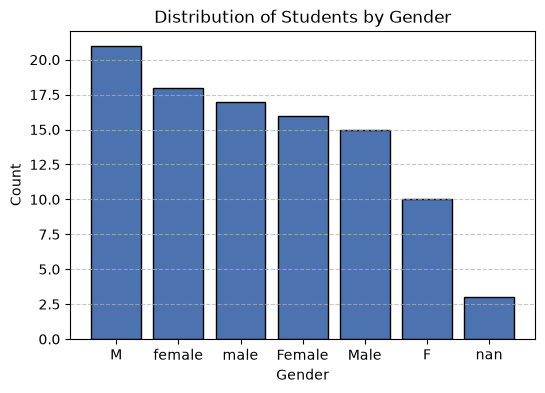

In [17]:
gender_counts = df['Gender'].value_counts(dropna=False).rename(index={float('nan'): 'Missing'})

plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index.astype(str), gender_counts.values, color='#4C72B0', edgecolor='black')
plt.title('Distribution of Students by Gender', fontsize=12)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bar chart City 

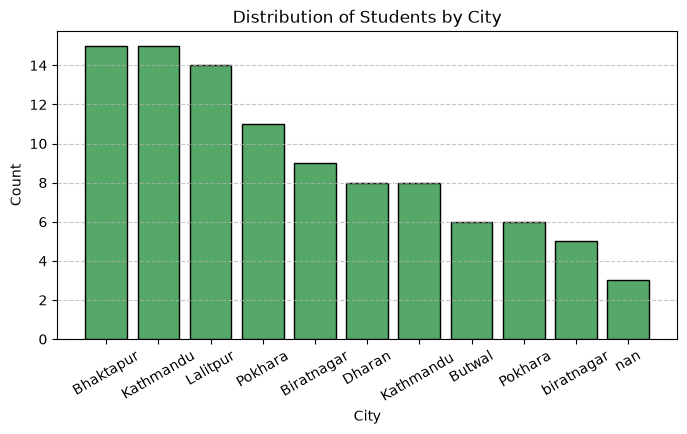

In [18]:
city_counts = df['City'].value_counts(dropna=False).rename(index={float('nan'): 'Missing'})

plt.figure(figsize=(8, 4))
plt.bar(city_counts.index.astype(str), city_counts.values, color='#55A868', edgecolor='black')
plt.title('Distribution of Students by City', fontsize=12)
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Pie Charts (Categorical Proportions)

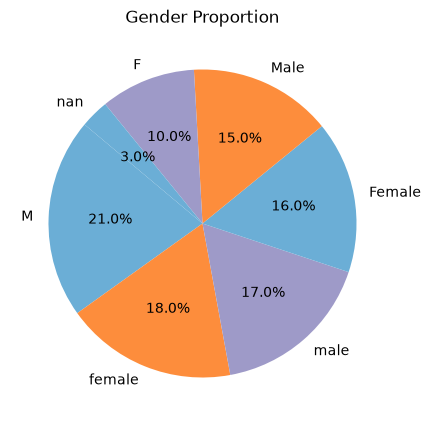

In [19]:
plt.figure(figsize=(5, 5))
plt.pie(gender_counts.values, labels=gender_counts.index.astype(str), autopct='%1.1f%%', startangle=140, colors=['#6baed6', '#fd8d3c', '#9e9ac8'])
plt.title('Gender Proportion', fontsize=12)
plt.show()

# Pie Chart: City Share

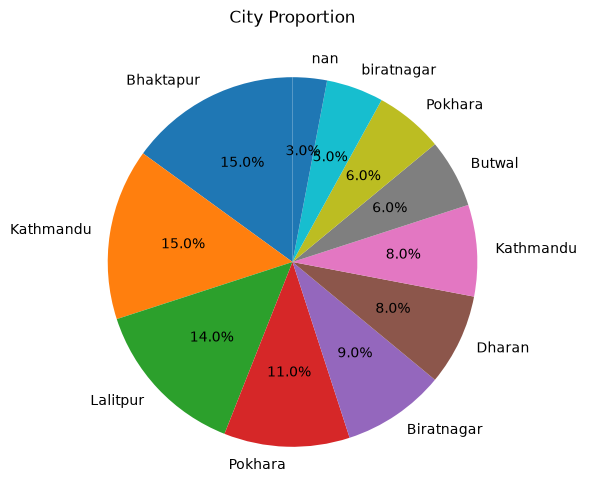

In [20]:
plt.figure(figsize=(6, 6))
plt.pie(city_counts.values, labels=city_counts.index.astype(str), autopct='%1.1f%%', startangle=90)
plt.title('City Proportion', fontsize=12)
plt.show()

# Histograms (Continuous Value Spread & Skewness)

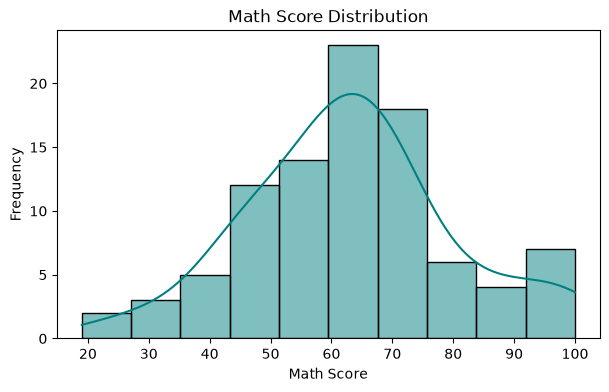

In [21]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Math'].dropna(), kde=True, bins=10, color='teal', edgecolor='black')
plt.title('Math Score Distribution', fontsize=12)
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

# Histogram: Attendance

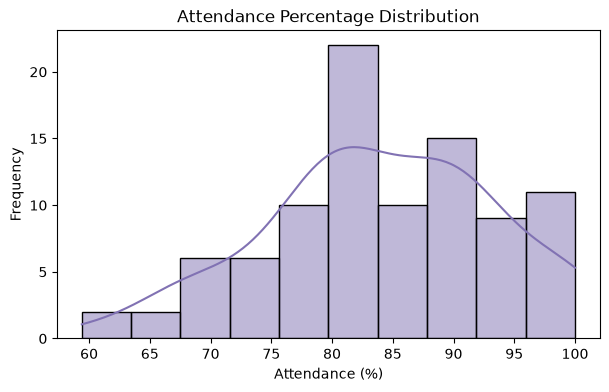

In [22]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Attendance'].dropna(), kde=True, bins=10, color='#8172B3', edgecolor='black')
plt.title('Attendance Percentage Distribution', fontsize=12)
plt.xlabel('Attendance (%)')
plt.ylabel('Frequency')
plt.show()

# Histograms for All Scores (Loop)

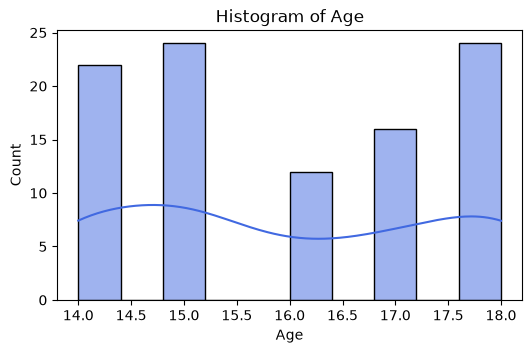

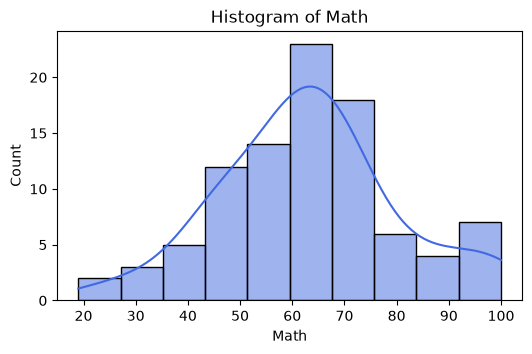

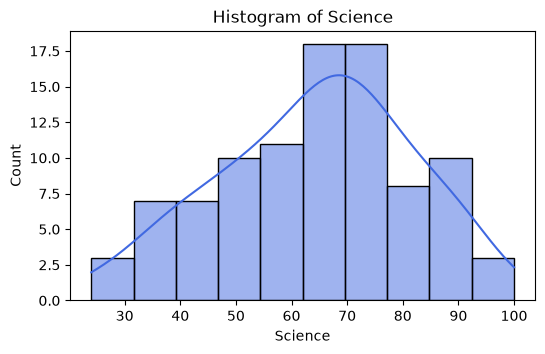

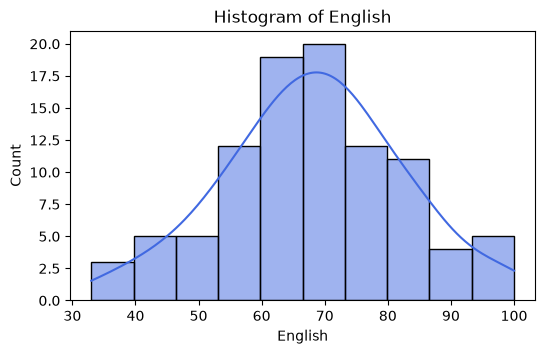

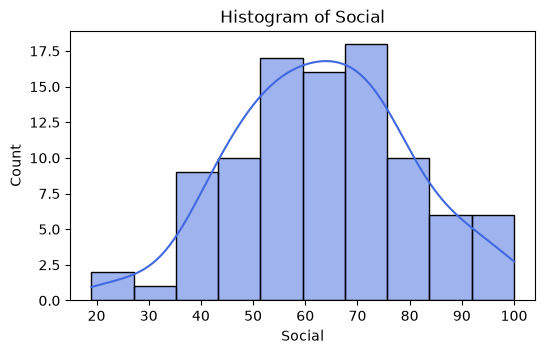

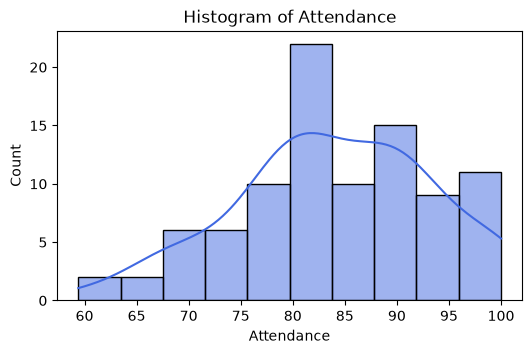

In [23]:
num_cols = ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance']

for col in num_cols:
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df[col].dropna(), kde=True, bins=10, color='royalblue', edgecolor='black')
    plt.title(f'Histogram of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Boxplots (Outliers & Quartile Distribution)

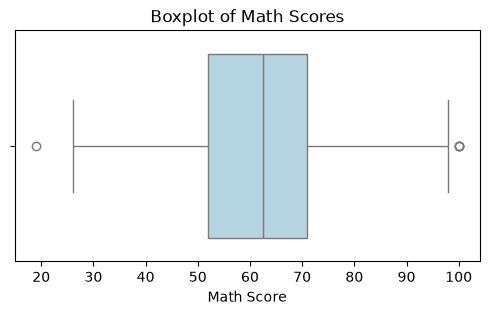

In [24]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Math'], color='lightblue')
plt.title('Boxplot of Math Scores', fontsize=12)
plt.xlabel('Math Score')
plt.show()

# Boxplot: Attendance

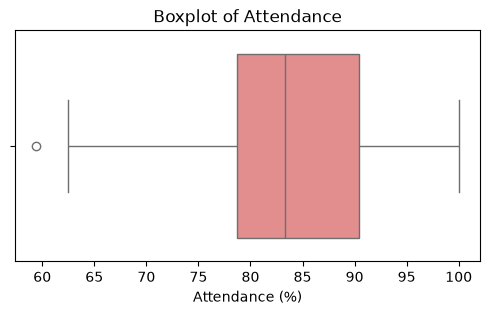

In [25]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Attendance'], color='lightcoral')
plt.title('Boxplot of Attendance', fontsize=12)
plt.xlabel('Attendance (%)')
plt.show()

# Boxplot: Comparing All Academic Subjects Together

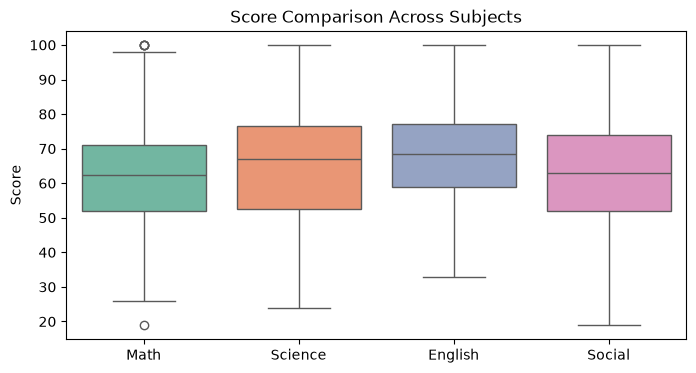

In [26]:
subjects = ['Math', 'Science', 'English', 'Social']

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[subjects], palette='Set2')
plt.title('Score Comparison Across Subjects', fontsize=12)
plt.ylabel('Score')
plt.show()

#  Bivariate & Multivariate Analysis

# Correlation Matrix Heatmap (Multivariate)

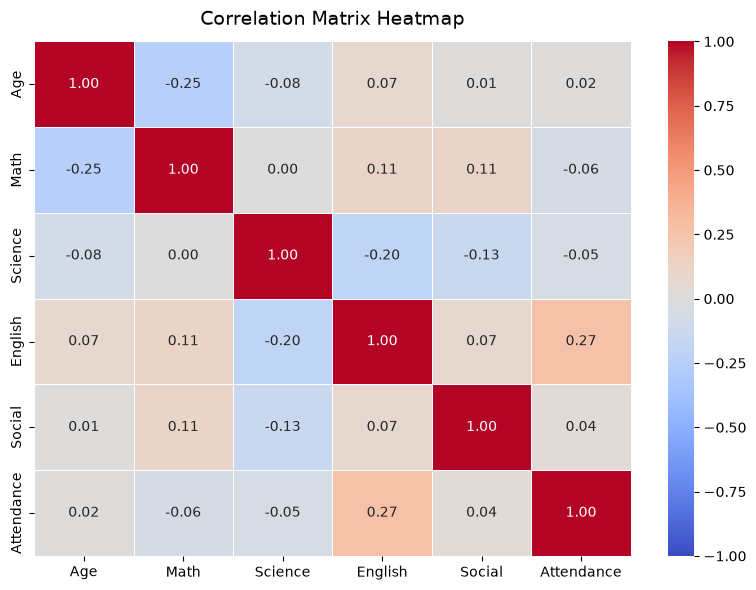

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix Heatmap", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Pairplot (Multivariate & Bivariate Overview)

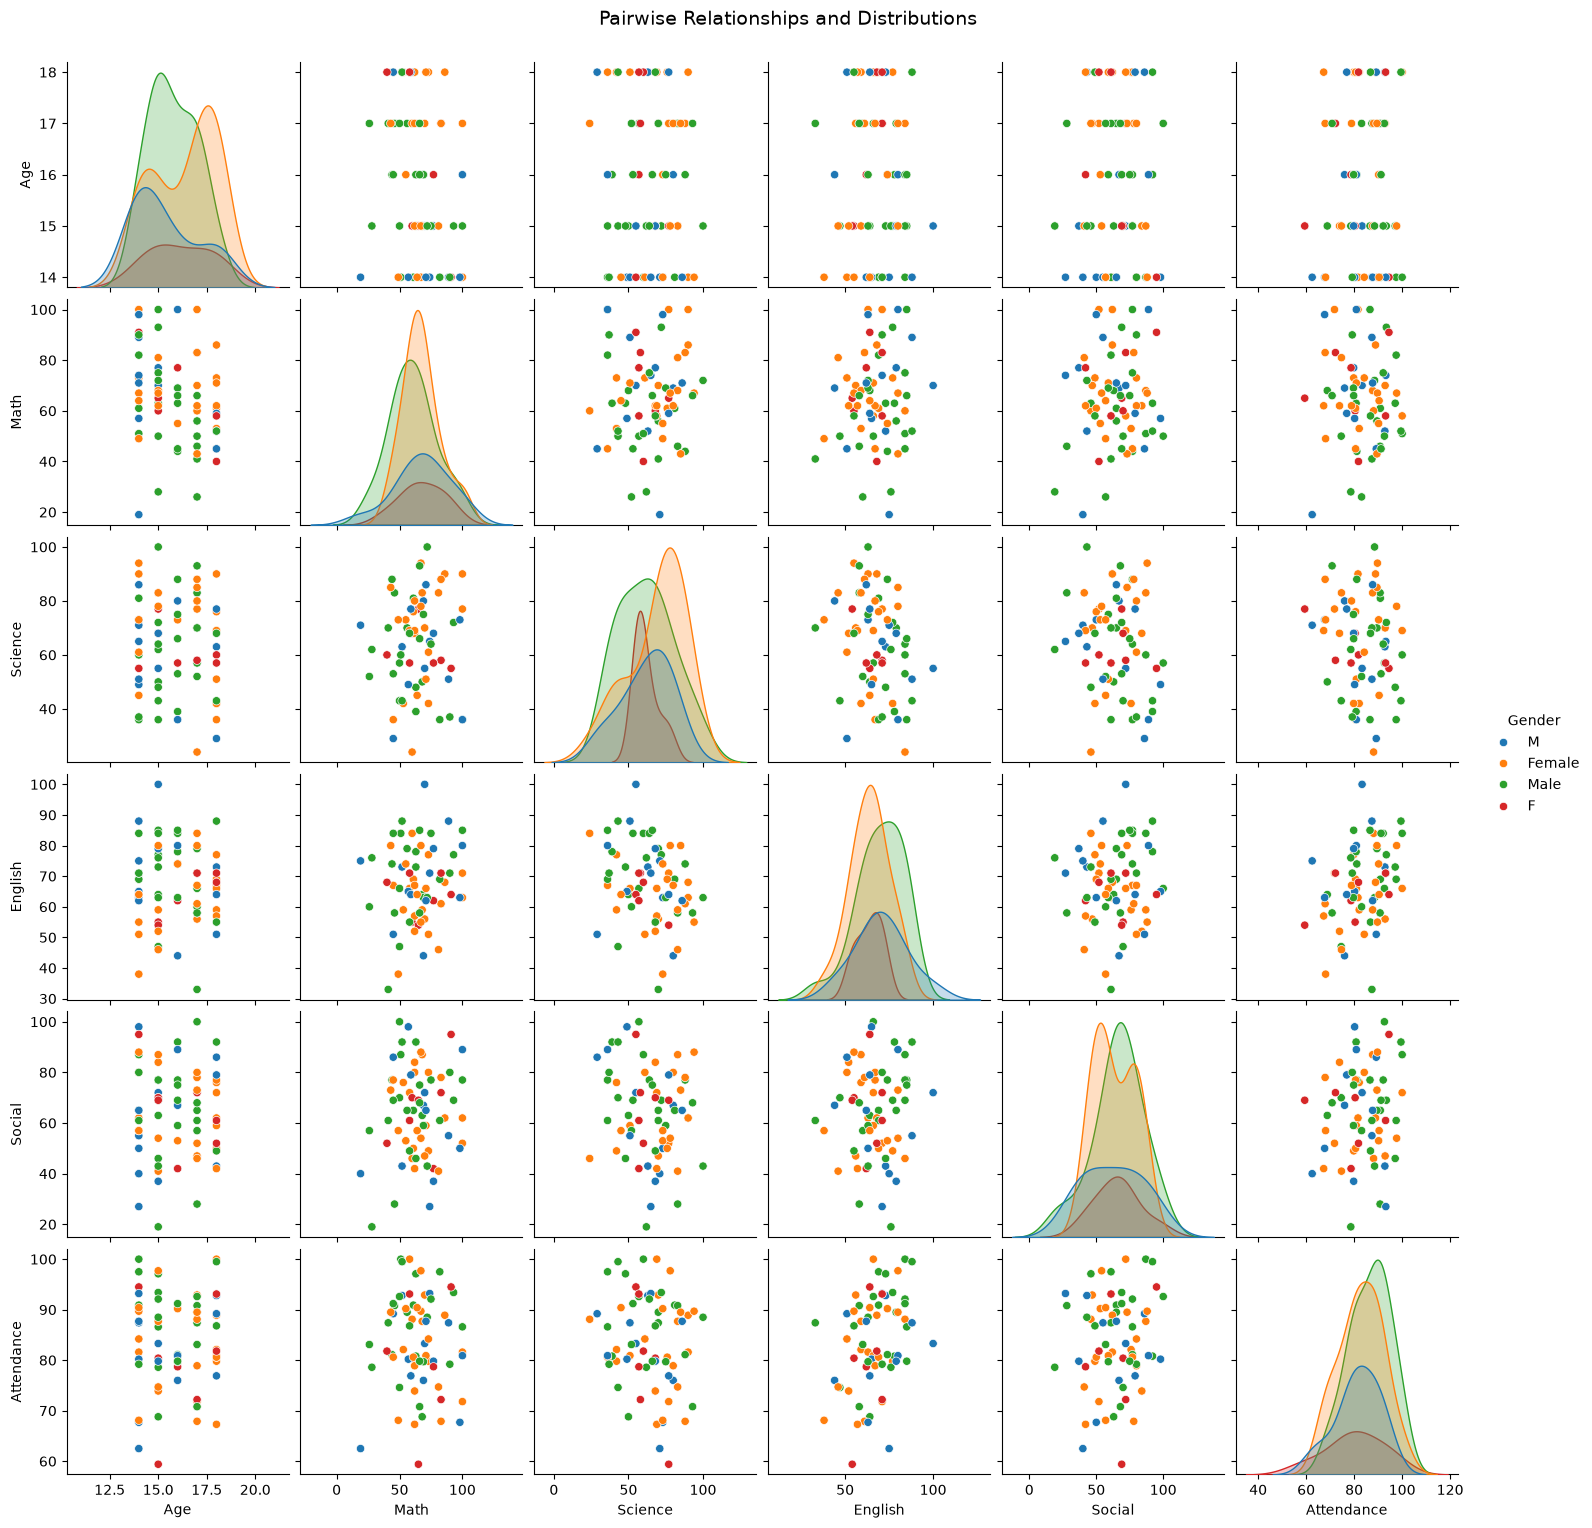

In [28]:
# Standardize Gender casing first if not done already
df['Gender'] = df['Gender'].str.capitalize()

numeric_cols = ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance']

sns.pairplot(
    df[numeric_cols + ['Gender']].dropna(),
    hue='Gender',
    diag_kind='kde',
    corner=False  # Set corner=True to hide the redundant upper triangle
)
plt.suptitle("Pairwise Relationships and Distributions", y=1.02, fontsize=14)
plt.show()

# Scatterplots (Bivariate Relationships)

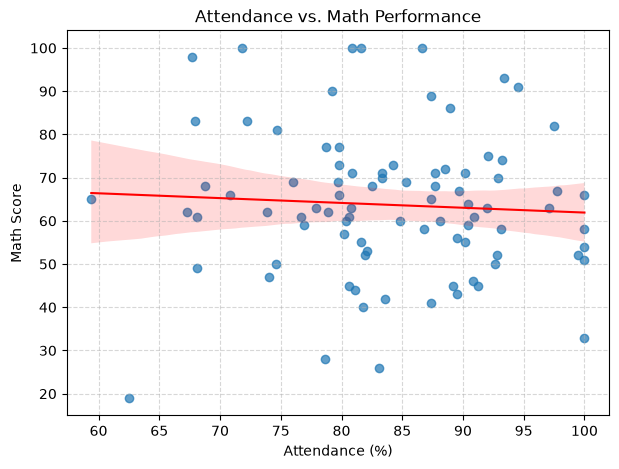

In [29]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x='Attendance',
    y='Math',
    scatter_kws={'alpha': 0.7, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
plt.title("Attendance vs. Math Performance", fontsize=12)
plt.xlabel("Attendance (%)")
plt.ylabel("Math Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Science vs. Math Scores (Grouped by Gender)

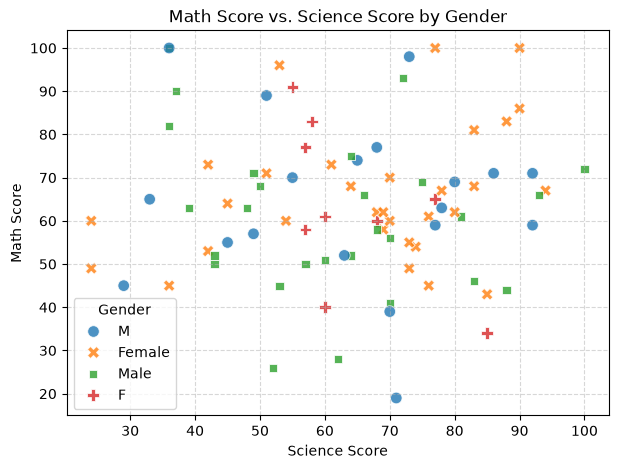

In [40]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='Science',
    y='Math',
    hue='Gender',
    style='Gender',
    s=70,
    alpha=0.8
)
plt.title("Math Score vs. Science Score by Gender", fontsize=12)
plt.xlabel("Science Score")
plt.ylabel("Math Score")
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Age vs. English Score (Grouped by City)

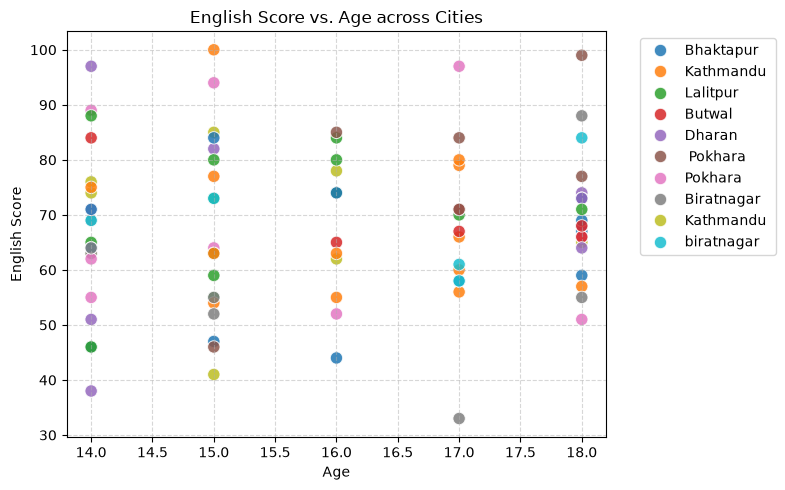

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Age',
    y='English',
    hue='City',
    s=80,
    alpha=0.85
)
plt.title("English Score vs. Age across Cities", fontsize=12)
plt.xlabel("Age")
plt.ylabel("English Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()